In [1]:
%pip install imbalanced-learn xgboost

StatementMeta(, 1f5a33d2-c69e-4026-b1be-9bb2498f6d99, 7, Finished, Available, Finished, True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 68.3 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Not uninstalling threadpoolctl at /home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages, outside environment /nfs4/pyenv-4fe84622-ce62-4edd-ba71-f4d58807af75
    Can't uninstall 'threadpoolctl'. No files were found to uninstall.
  Attempting uninstall: joblib
    Found existing installation: joblib 1.2.0
    Not uninstalling joblib at /home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages, outside environment /nfs4/pyenv-4fe84622-ce62-4edd-ba71-f4d58807af75
    Can't uninstall 'joblib'. No files were found to uninstall.
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-l

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Read from Silver layer (no prefix)
df_silver = spark.table("silver_transactions")

feature_cols = [f"V{i}" for i in range(1, 29)] + [
    "Amount_log", "Amount_percentile",
    "V1_abs", "V2_abs", "V3_abs", "V4_abs", "V5_abs",
    "V1_V2_interaction", "V1_Amount_interaction"
]

pdf = df_silver.select(feature_cols + ["Class"]).toPandas()

X = pdf[feature_cols]
y = pdf["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} records")
print(f"Test set: {X_test.shape[0]} records")
print(f"Training fraud rate: {y_train.mean() * 100:.4f}%")
print(f"Test fraud rate: {y_test.mean() * 100:.4f}%")

StatementMeta(, 1f5a33d2-c69e-4026-b1be-9bb2498f6d99, 9, Finished, Available, Finished, False)

Training set: 454904 records
Test set: 113726 records
Training fraud rate: 50.0000%
Test fraud rate: 50.0000%


In [4]:
print(f"Class distribution in training set:")
print(f"{y_train.value_counts().to_dict()}")
print(f"\nFraud rate: {y_train.mean() * 100:.2f}%")
print(f"Dataset is already balanced — skipping SMOTE")

# Use the scaled training data directly (no resampling needed)
X_train_resampled = X_train_scaled
y_train_resampled = y_train

StatementMeta(, 1f5a33d2-c69e-4026-b1be-9bb2498f6d99, 11, Finished, Available, Finished, False)

Class distribution in training set:
{0: 227452, 1: 227452}

Fraud rate: 50.00%
Dataset is already balanced — skipping SMOTE


In [5]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, precision_recall_curve, 
    average_precision_score
)

# Set the MLflow experiment
EXPERIMENT_NAME = "fraud-detection-experiment"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

StatementMeta(, 1f5a33d2-c69e-4026-b1be-9bb2498f6d99, 12, Finished, Available, Finished, False)

2026/03/24 23:12:44 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection-experiment' does not exist. Creating a new experiment.


Experiment: fraud-detection-experiment
Tracking URI: sds://pbipeastus2-eastus.pbidedicated.windows.net/webapi/capacities/38bb2f17-dca7-41b3-9c89-5abb94a7e9ef/workloads/ML/ML/Automatic/workspaceid/633902ff-9ec7-4005-a95a-6550752cf8cf/


In [6]:
from sklearn.linear_model import LogisticRegression

with mlflow.start_run(run_name="logistic_regression"):
    # Log parameters
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("C", 1.0)
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("smote_applied", True)
    mlflow.log_param("smote_ratio", 0.5)
    mlflow.log_param("n_features", len(feature_cols))
    
    # Train model
    lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    lr_model.fit(X_train_resampled, y_train_resampled)
    
    # Predict on test set (using original scaled test data, NOT resampled)
    y_pred = lr_model.predict(X_test_scaled)
    y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("auc_roc", auc_roc)
    mlflow.log_metric("avg_precision", avg_precision)
    
    # Log confusion matrix as artifact
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, 
                          index=['Actual Legit', 'Actual Fraud'],
                          columns=['Predicted Legit', 'Predicted Fraud'])
    cm_df.to_csv("/tmp/confusion_matrix_lr.csv")
    mlflow.log_artifact("/tmp/confusion_matrix_lr.csv")
    
    # Log the model
    mlflow.sklearn.log_model(lr_model, artifact_path="model")
    
    print("=== Logistic Regression Results ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc_roc:.4f}")
    print(f"\nConfusion Matrix:\n{cm_df}")

StatementMeta(, 1f5a33d2-c69e-4026-b1be-9bb2498f6d99, 13, Finished, Available, Finished, False)

=== Logistic Regression Results ===
Accuracy:  0.9671
Precision: 0.9783
Recall:    0.9554
F1 Score:  0.9667
AUC-ROC:   0.9943

Confusion Matrix:
              Predicted Legit  Predicted Fraud
Actual Legit            55658             1205
Actual Fraud             2534            54329


In [9]:
from xgboost import XGBClassifier

with mlflow.start_run(run_name="xgboost"):
    scale_pos_weight = 1.0  # Already balanced dataset
    
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 8)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_param("smote_applied", False)
    mlflow.log_param("n_features", len(feature_cols))
    
    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='aucpr'
    )
    xgb_model.fit(
        X_train_scaled, y_train,
        eval_set=[(X_test_scaled, y_test)],
        verbose=False
    )
    
    y_pred = xgb_model.predict(X_test_scaled)
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("auc_roc", auc_roc)
    mlflow.log_metric("avg_precision", avg_precision)
    
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    feature_importance.to_csv("/tmp/feature_importance_xgb.csv", index=False)
    mlflow.log_artifact("/tmp/feature_importance_xgb.csv")
    
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, 
                          index=['Actual Legit', 'Actual Fraud'],
                          columns=['Predicted Legit', 'Predicted Fraud'])
    cm_df.to_csv("/tmp/confusion_matrix_xgb.csv")
    mlflow.log_artifact("/tmp/confusion_matrix_xgb.csv")
    
    mlflow.sklearn.log_model(xgb_model, artifact_path="model")
    
    print("=== XGBoost Results ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc_roc:.4f}")
    print(f"\nTop 10 Features:\n{feature_importance.head(10)}")
    print(f"\nConfusion Matrix:\n{cm_df}")

StatementMeta(, 1f5a33d2-c69e-4026-b1be-9bb2498f6d99, 16, Finished, Available, Finished, False)

=== XGBoost Results ===
Accuracy:  0.9997
Precision: 0.9994
Recall:    1.0000
F1 Score:  0.9997
AUC-ROC:   1.0000

Top 10 Features:
              feature  importance
13                V14    0.611167
3                  V4    0.069618
11                V12    0.024269
32             V3_abs    0.022174
7                  V8    0.017887
35  V1_V2_interaction    0.016354
0                  V1    0.015054
1                  V2    0.013299
9                 V10    0.013240
2                  V3    0.011736

Confusion Matrix:
              Predicted Legit  Predicted Fraud
Actual Legit            56831               32
Actual Fraud                0            56863


StatementMeta(, 1f5a33d2-c69e-4026-b1be-9bb2498f6d99, 17, Finished, Available, Finished, False)

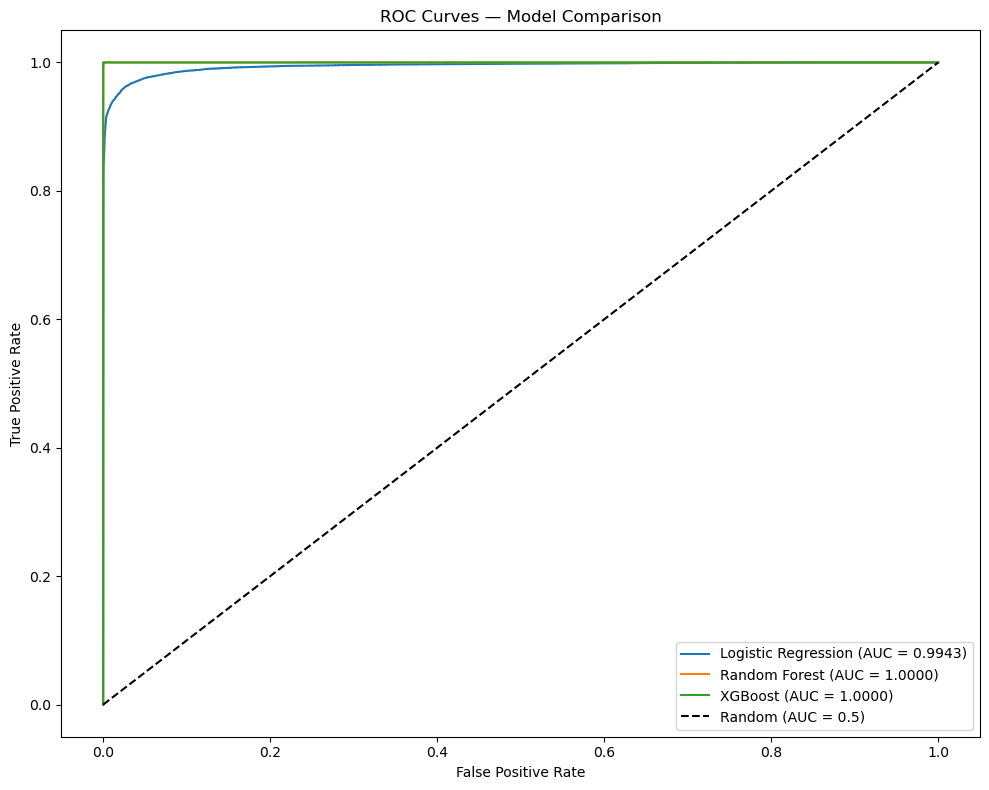

In [10]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Retrain quickly for ROC comparison (or store predictions from above)
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [11]:
# Find the best run based on AUC-ROC
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.auc_roc DESC"]
)

# Display comparison table
print("Model Comparison:")
print(runs[["run_id", "params.model_type", "metrics.auc_roc", 
            "metrics.precision", "metrics.recall", "metrics.f1_score"]].head())

# Get the best run
best_run = runs.iloc[0]
best_run_id = best_run["run_id"]
best_model_type = best_run["params.model_type"]
best_auc = best_run["metrics.auc_roc"]

print(f"\nBest model: {best_model_type}")
print(f"Best AUC-ROC: {best_auc:.4f}")
print(f"Best Run ID: {best_run_id}")

# Register the best model in MLflow Model Registry
model_uri = f"runs:/{best_run_id}/model"
model_name = "fraud-detection-model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=model_name
)

print(f"\nModel registered: {model_name}")
print(f"Version: {registered_model.version}")

StatementMeta(, 1f5a33d2-c69e-4026-b1be-9bb2498f6d99, 18, Finished, Available, Finished, False)

Model Comparison:
                                 run_id   params.model_type  metrics.auc_roc  \
0  c4290098-6bc7-4252-b2cd-984092b87ba9             XGBoost         0.999986   
1  06f07b34-9a65-48fa-860c-27d2f466cc99        RandomForest         0.999973   
2  38d72f21-ae00-49cd-842b-ee647ab2b1fc  LogisticRegression         0.994272   

   metrics.precision  metrics.recall  metrics.f1_score  
0           0.999438        1.000000          0.999719  
1           0.999244        0.999719          0.999481  
2           0.978302        0.955437          0.966734  

Best model: XGBoost
Best AUC-ROC: 1.0000
Best Run ID: c4290098-6bc7-4252-b2cd-984092b87ba9


Successfully registered model 'fraud-detection-model'.
Created version '1' of model 'fraud-detection-model'.
